# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos 'df_furniture.csv'
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus ultimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [14]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [15]:
# Importa los datos 'df_furniture.csv'
df = pd.read_csv('data/df_furniture.csv', parse_dates=['Month'])
df.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


In [16]:
# Mirar tipo de variables y nulos
df.info()
# Hay nulos en la columna "Month"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     326 non-null    datetime64[ns]
 1   furniture_price_adjusted  331 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.3 KB


In [17]:
# Cambiar el nombre de la columna a fecha, no es el mes
df.rename(columns={'Month' : 'date'}, inplace=True)

In [18]:
# Miramos dónde están los nulos en date
df[df['date'].isna()]

,date,furniture_price_adjusted
15,NaT,2457.704334
21,NaT,2715.938414
39,NaT,2857.008678
40,NaT,3086.648631
60,NaT,3298.628987


## 2. Tratar la fecha como texto y parsear

In [19]:
# Rellenar los valores nulos mediante una interpolación linear 
df['date'] = df['date'].interpolate(method='linear')

In [20]:
df['date'] = pd.date_range(df['date'].min(), df['date'].max(), freq='MS')

In [21]:
df['fecha_str'] = df['date'].astype(str)

In [22]:
# Crea una columna para el año, mes y dia
df[['year', 'month', 'day']] = df['fecha_str'].str.split('-', expand=True)
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['day'] = df['day'].astype(int)

In [ ]:
# Crear la de fecha, en formato datetime de pandas
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.head()

,date,furniture_price_adjusted,fecha_str,year,month,day,new_date
0,1992-01-01,2073.432724,1992-01-01,1992,1,1,1992-01-01
1,1992-02-01,2114.485812,1992-02-01,1992,2,1,1992-02-01
2,1992-03-01,2260.570891,1992-03-01,1992,3,1,1992-03-01
3,1992-04-01,2255.103236,1992-04-01,1992,4,1,1992-04-01
4,1992-05-01,2331.414618,1992-05-01,1992,5,1,1992-05-01


## 3. ¿De qué fecha a qué fecha va el histórico?

In [23]:
print('La fecha mínima es ', df['date'].min(), 'y la máxima ', df['date'].max())

La fecha mínima es  1992-01-01 00:00:00 y la máxima  2019-07-01 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

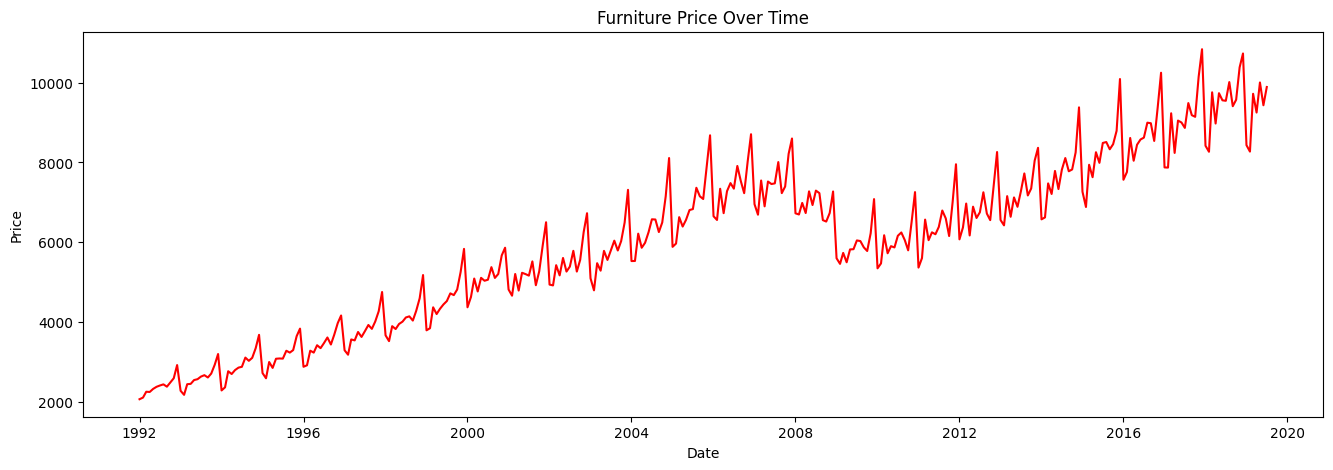

In [27]:
plt.figure(figsize=(16,5))
plt.plot(df['date'], df['furniture_price_adjusted'], '-r')
plt.title('Furniture Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show();

In [29]:
# La serie presenta:
# 1. Tendencia creciente a largo plazo
# 2. Estacionalidad anual (picos y valles periódicos)
# 3. Por tanto, NO es estacionaria

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?

In [ ]:
#1
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['furniture_price_adjusted'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


ADF Statistic: -1.1285507258736922
p-value: 0.7035529748089993


In [33]:
# p-valor > 0.05 -> NO es estacionaria

In [31]:
#2
from statsmodels.tsa.stattools import kpss
result = kpss(df['furniture_price_adjusted'], regression='ct')
print(f'KPSS Statistic: {result[0]}')
print(f'p-value: {result[1]}')

KPSS Statistic: 0.301041409977063
p-value: 0.01


/var/folders/tw/q38f_br56j93gr_g2pvmv9_m0000gn/T/ipykernel_1301/1408930541.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df['furniture_price_adjusted'], regression='ct')


In [32]:
# Si p-value < 0.05 -> NO es estacionaria

## 6. ¿Conoces algún método para representar mejor la tendencia?

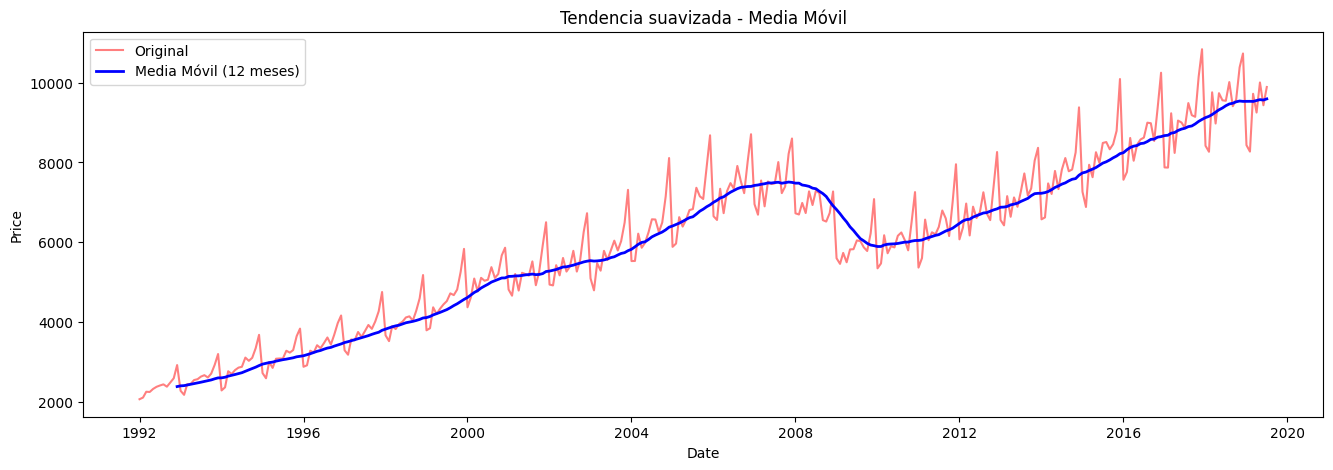

In [34]:
# Media móvil para visualizar la tendencia
rolling_mean = df['furniture_price_adjusted'].rolling(window=12).mean()

plt.figure(figsize=(16,5))
plt.plot(df['date'], df['furniture_price_adjusted'], '-r', alpha=0.5, label='Original')
plt.plot(df['date'], rolling_mean, '-b', linewidth=2, label='Media Móvil (12 meses)')
plt.title('Tendencia suavizada - Media Móvil')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show();

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

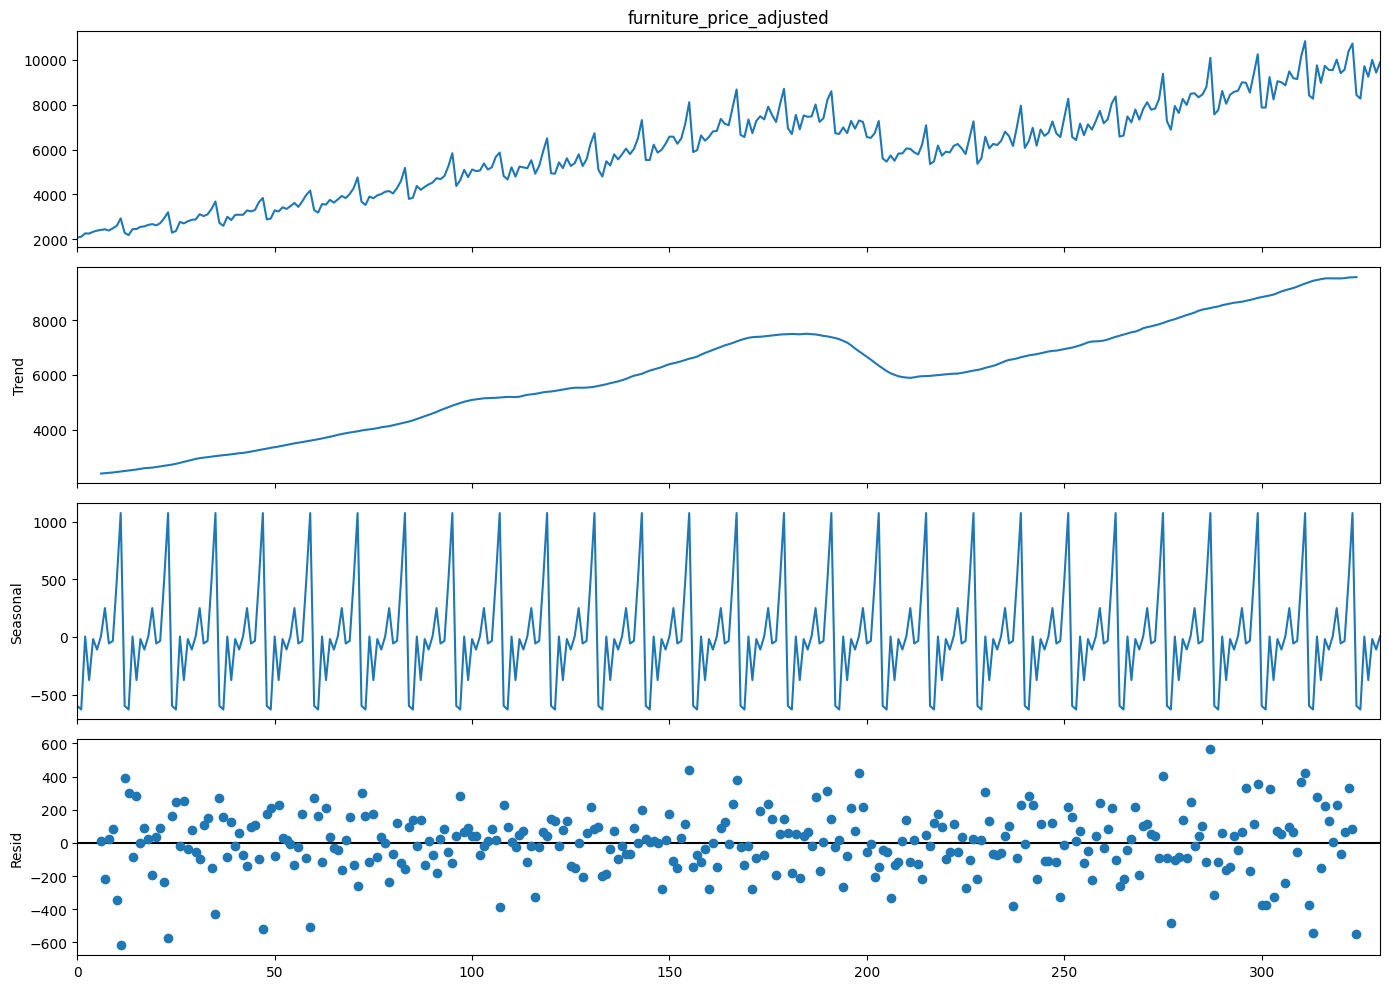

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición de la serie
decomposition = seasonal_decompose(
    df['furniture_price_adjusted'], 
    model='additive',  # o 'multiplicative'
    period=12          # estacionalidad anual
)

# Visualizar los 4 componentes
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

<Figure size 1400x500 with 0 Axes>

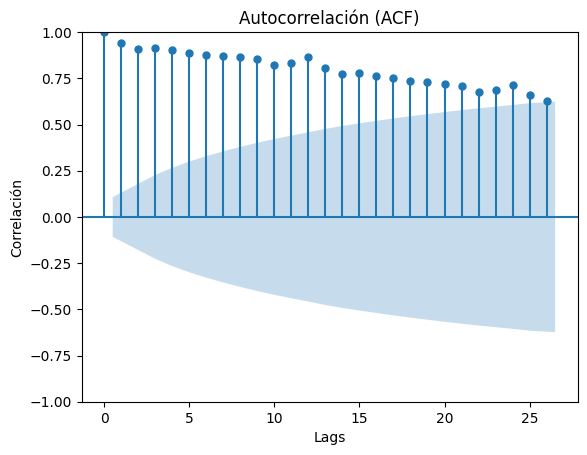

In [42]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))
plot_acf(df['furniture_price_adjusted'])
plt.title('Autocorrelación (ACF)')
plt.xlabel('Lags')
plt.ylabel('Correlación')
plt.show();

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

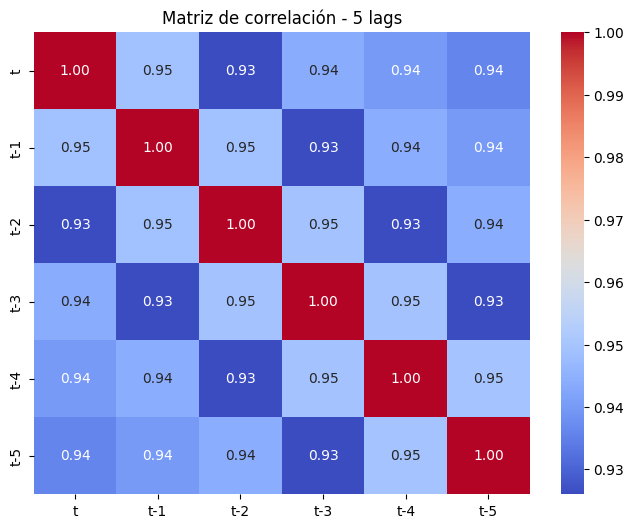

In [43]:
# Crear DataFrame con los 5 lags
df_lags = pd.DataFrame({'t': df['furniture_price_adjusted']})
for i in range(1, 6):
    df_lags[f't-{i}'] = df['furniture_price_adjusted'].shift(i)

df_lags.dropna(inplace=True)

# Matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_lags.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación - 5 lags')
plt.show()

## 10. Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?

<Figure size 1400x500 with 0 Axes>

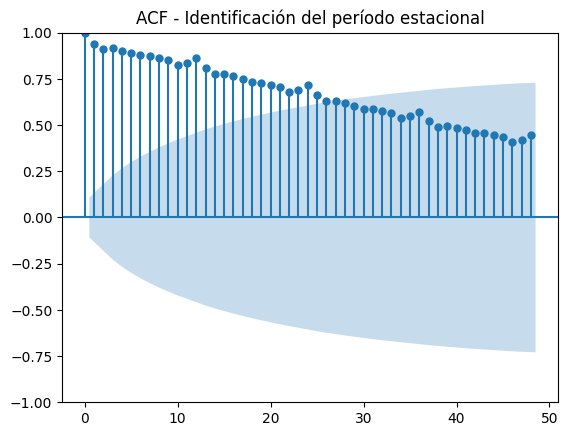

0     -598.016372
1     -629.539170
2        3.339190
3     -374.449675
4      -18.635761
5     -109.371696
6        6.314455
7      249.802691
8      -57.130087
9      -35.087178
10     489.010604
11    1073.763000
12    -598.016372
13    -629.539170
14       3.339190
15    -374.449675
16     -18.635761
17    -109.371696
18       6.314455
19     249.802691
20     -57.130087
21     -35.087178
22     489.010604
23    1073.763000
Name: seasonal, dtype: float64


In [45]:
from statsmodels.graphics.tsaplots import plot_acf

# Observar los picos en el ACF
plt.figure(figsize=(14, 5))
plot_acf(df['furniture_price_adjusted'], lags=48)
plt.title('ACF - Identificación del período estacional')
plt.show();

# También con la descomposición
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['furniture_price_adjusted'], model='additive', period=12)
print(decomp.seasonal[:24])  # Ver los primeros 2 ciclos

El patrón estacional se repite cada 12 instantes (meses), es decir, tiene una estacionalidad anual

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

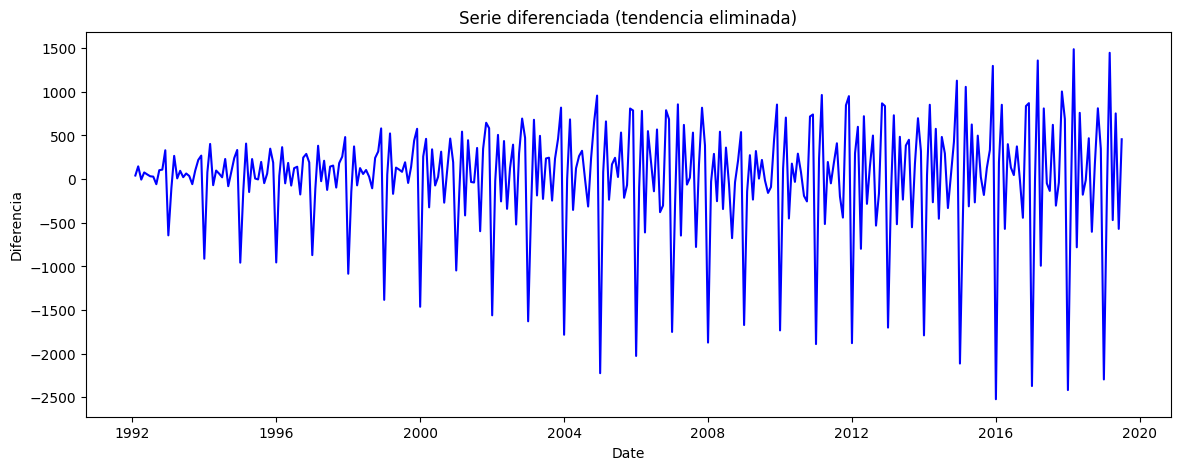

p-value tras diferenciación: 0.025288379295704228


In [46]:
# Diferenciación
df_diff = df['furniture_price_adjusted'].diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(df['date'][1:], df_diff, '-b')
plt.title('Serie diferenciada (tendencia eliminada)')
plt.xlabel('Date')
plt.ylabel('Diferencia')
plt.show()

# Verificar estacionariedad tras diferenciar
result = adfuller(df_diff)
print(f'p-value tras diferenciación: {result[1]}')

p-value < 0.05 -> la serie es estacionaria